In [2]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
import ast

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 통계 분석
from scipy import stats
from scipy.stats import shapiro, levene, ttest_ind, chi2_contingency, f_oneway
from scipy.stats import mannwhitneyu, fisher_exact, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
import pingouin as pg

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # maxOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 6)

# 시드 설정
np.random.seed(42)

print("="*60)
print("라이브러리 로드 완료!")
print("한글 폰트 설정 완료!")
print("="*60)

라이브러리 로드 완료!
한글 폰트 설정 완료!


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

SB_DEEP_GREEN = '#1E3932'
SB_GREEN      = '#006241'
SB_LIGHT_GREEN = '#D4E9E2'
SB_GOLD       = '#CBA258'
SB_GREY       = '#A2AAAD'
SB_BLACK      = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic',
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
    'xtick.color': SB_BLACK,
    'ytick.color': SB_BLACK,
    'axes.spines.top': False,    
    'axes.spines.right': False, 
    'patch.edgecolor': 'none'    
})


sns.set_palette([SB_GREEN, SB_GOLD, SB_DEEP_GREEN, SB_LIGHT_GREEN, SB_GREY])

In [4]:
trans_df = pd.read_csv("../../Data/transactions_260325.csv")
trans_df

,tx_key,person,customer_id,time,amount,tx_occurrence,time_days,gender,age,became_member_on,income,income_missing,age_missing,linked_reward_offer_cnt,reward_offer_family_list,reward_offer_label_list,reward_offer_id_list,bonus_reward_sum,txn_offer_type
0,0009655768c64bdeb2e877511632db8f|228|22.16|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,228,22.16,1,10,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
1,0009655768c64bdeb2e877511632db8f|414|8.57|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,414,8.57,1,18,M,33.0,2017-04-21,72000.0,0,0,1,['bogo'],['bogo_4'],['f19421c1d4aa40978ebb69ca19b0e20d'],5,bogo
2,0009655768c64bdeb2e877511632db8f|528|14.11|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,528,14.11,1,23,M,33.0,2017-04-21,72000.0,0,0,1,['discount'],['discount_3'],['fafdcd668e3743c1bb461111dcafc2a4'],2,discount
3,0009655768c64bdeb2e877511632db8f|552|13.56|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,552,13.56,1,24,M,33.0,2017-04-21,72000.0,0,0,0,[],[],[],0,normal
4,0009655768c64bdeb2e877511632db8f|576|10.27|1,0009655768c64bdeb2e877511632db8f,0009655768c64bdeb2e877511632db8f,576,10.27,1,25,M,33.0,2017-04-21,72000.0,0,0,1,['discount'],['discount_4'],['2906b810c7d4411798c6938adc9daaa5'],2,discount
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138948,ffff82501cea40309d5fdd7edcca4a07|576|14.23|1,ffff82501cea40309d5fdd7edcca4a07,ffff82501cea40309d5fdd7edcca4a07,576,14.23,1,25,F,45.0,2016-11-25,62000.0,0,0,1,['discount'],['discount_4'],['2906b810c7d4411798c6938adc9daaa5'],2,discount
138949,ffff82501cea40309d5fdd7edcca4a07|606|10.12|1,ffff82501cea40309d5fdd7edcca4a07,ffff82501cea40309d5fdd7edcca4a07,606,10.12,1,26,F,45.0,2016-11-25,62000.0,0,0,0,[],[],[],0,normal
138950,ffff82501cea40309d5fdd7edcca4a07|60|16.06|1,ffff82501cea40309d5fdd7edcca4a07,ffff82501cea40309d5fdd7edcca4a07,60,16.06,1,3,F,45.0,2016-11-25,62000.0,0,0,1,['discount'],['discount_3'],['fafdcd668e3743c1bb461111dcafc2a4'],2,discount
138951,ffff82501cea40309d5fdd7edcca4a07|648|18.91|1,ffff82501cea40309d5fdd7edcca4a07,ffff82501cea40309d5fdd7edcca4a07,648,18.91,1,28,F,45.0,2016-11-25,62000.0,0,0,0,[],[],[],0,normal


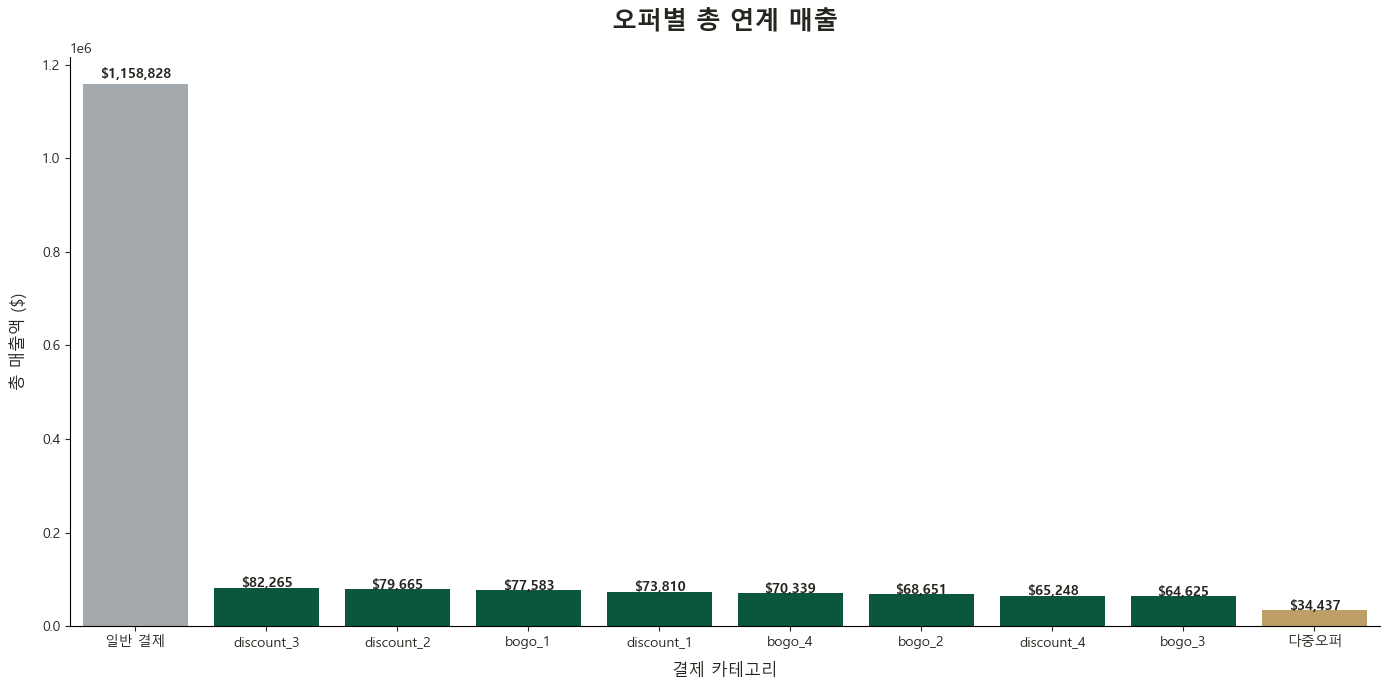

  final_category      amount
0          일반 결제  1158828.29
1     discount_3    82265.18
2     discount_2    79665.13
3         bogo_1    77583.39
4     discount_1    73810.25
5         bogo_4    70338.90
6         bogo_2    68650.76
7     discount_4    65247.52
8         bogo_3    64625.47
9           다중오퍼    34437.08


In [5]:
# 2. 카테고리명으로 데이터 정리
def get_final_label(row):
    if row['txn_offer_type'] == 'normal':
        return '일반 결제'
    elif row['txn_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼(bogo, discount)인 경우 리스트 안에 있는 라벨(예: bogo_4)을 꺼내옵니다.
        # 데이터가 문자열 형태의 리스트("['bogo_4']")이므로 ast.literal_eval을 사용합니다.
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['txn_offer_type']

trans_df['final_category'] = trans_df.apply(get_final_label, axis=1)

# 3. 카테고리별 총 매출액 계산
revenue_summary = trans_df.groupby('final_category')['amount'].sum().reset_index()
revenue_summary = revenue_summary.sort_values(by='amount', ascending=False).reset_index(drop=True)

# 4. 시각화 ( 스타벅스 테마)
SB_GREEN       = '#006241'
SB_GOLD        = '#CBA258'
SB_GREY        = '#A2AAAD'
SB_BLACK       = '#27251F'

plt.rcParams.update({
    'font.family': 'Malgun Gothic', # 맥북은 'AppleGothic'
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
})

plt.figure(figsize=(14, 7))

# 카테고리에 따른 색상 배정 함수
def set_color(cat):
    if cat == '일반 결제': return SB_GREY
    elif cat == '다중오퍼': return SB_GOLD
    else: return SB_GREEN

colors = [set_color(cat) for cat in revenue_summary['final_category']]

# 막대그래프 그리기
ax = sns.barplot(data=revenue_summary, x='final_category', y='amount', palette=colors)

plt.title('오퍼별 총 연계 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('총 매출액 ($)', fontsize=12, labelpad=10)

# 막대 위에 금액 표시 (천 단위 콤마 추가)
for i, v in enumerate(revenue_summary['amount']):
    ax.text(i, v + (v * 0.01), f"${v:,.0f}", ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. 결과 데이터 출력
print(revenue_summary)

In [ ]:


# 2. 선샌니의 카테고리 분류 로직 적용 (일반 결제 / 다중오퍼 / 개별 오퍼)
def get_final_label(row):
    if row['txn_offer_type'] == 'normal':
        return '일반 결제'
    elif row['txn_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼는 리스트에서 라벨 추출
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['txn_offer_type']

trans_df['final_category'] = trans_df.apply(get_final_label, axis=1)

# 3. 카테고리별 매출 합계 계산 
revenue_summary = trans_df.groupby('final_category')['amount'].sum().reset_index()

# 4. 합계 비교
sum_of_categories = revenue_summary['amount'].sum() # 표에 나온 항목들의 총합
actual_total_revenue = trans_df['amount'].sum()    # 원본 결제 데이터의 전체 총합

print(f"1. 카테고리별 매출 합계: ${sum_of_categories:,.2f}")
print(f"2. 실제 전체 매출 총합: ${actual_total_revenue:,.2f}")
print(f"3. 두 값의 차이: {sum_of_categories - actual_total_revenue}")

1. 카테고리별 매출 합계: $1,775,451.97
2. 실제 전체 매출 총합: $1,775,451.97
3. 두 값의 차이: 0.0


In [7]:

# 2. 4대 카테고리 매핑 (normal -> 일반 결제, multi -> 다중오퍼 등)
category_map = {
    'normal': '일반 결제',
    'discount': 'discount',
    'bogo': 'bogo',
    'multi': '다중오퍼'
}
trans_df['final_group'] = trans_df['txn_offer_type'].map(category_map)

# 3. 카테고리별 총 매출액 계산
revenue_summary = trans_df.groupby('final_group')['amount'].sum().reset_index()
revenue_summary.rename(columns={'amount': '총매출'}, inplace=True)

# 4. 출력 순서 고정 (일반 결제 -> discount -> bogo -> 다중오퍼)
order_list = ['일반 결제', 'discount', 'bogo', '다중오퍼']
revenue_summary['final_group'] = pd.Categorical(revenue_summary['final_group'], categories=order_list, ordered=True)
revenue_summary = revenue_summary.sort_values('final_group').reset_index(drop=True)

# 결과 확인
display(revenue_summary)

,final_group,총매출
0,일반 결제,1158828.29
1,discount,300988.08
2,bogo,281198.52
3,다중오퍼,34437.08


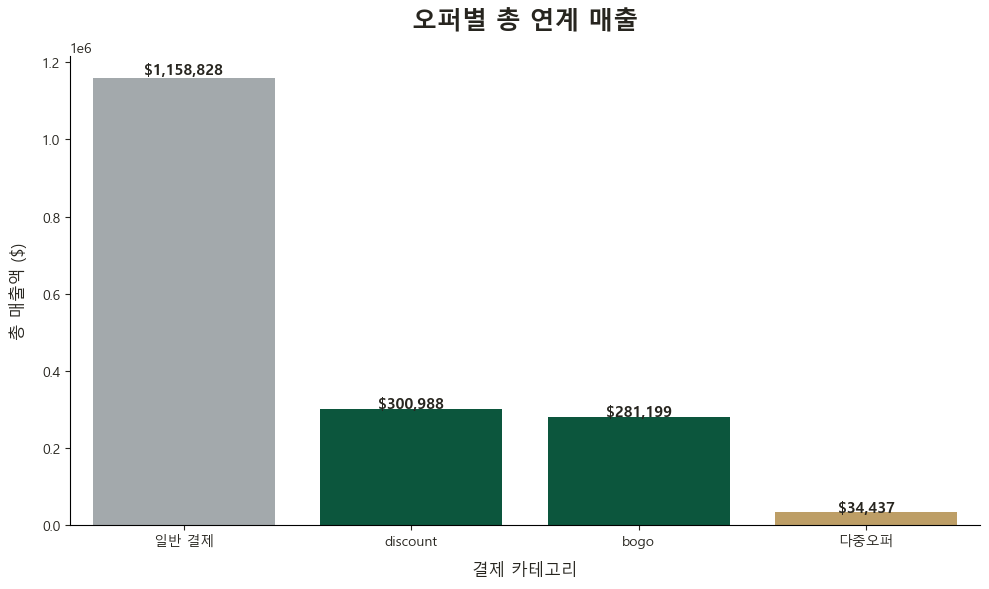

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

#  스타벅스 컬러 설정 
SB_GREEN  = '#006241'
SB_GOLD   = '#CBA258'
SB_GREY   = '#A2AAAD'
SB_BLACK  = '#27251F'

# 한글 폰트 설정 (맥북은 'AppleGothic')
plt.rcParams.update({'font.family': 'Malgun Gothic', 'axes.unicode_minus': False})

plt.figure(figsize=(10, 6))

# 색상 팔레트 설정
colors = [SB_GREY, SB_GREEN, SB_GREEN, SB_GOLD]

# 막대그래프 그리기
ax = sns.barplot(data=revenue_summary, x='final_group', y='총매출', palette=colors)

plt.title('오퍼별 총 연계 매출', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('총 매출액 ($)', fontsize=12, labelpad=10)

# 막대 위에 금액 표시 (천 단위 콤마 추가)
for i, v in enumerate(revenue_summary['총매출']):
    ax.text(i, v + (v * 0.01), f"${v:,.0f}", ha='center', fontsize=11, fontweight='bold', color=SB_BLACK)

plt.tight_layout()
plt.show()

In [9]:

# 2. 10개 카테고리 정의 (일반 결제, 다중오퍼, 개별 오퍼 8개)
def get_detailed_label(row):
    if row['txn_offer_type'] == 'normal':
        return '일반 결제'
    elif row['txn_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼는 리스트 안의 라벨(예: bogo_1)을 직접 가져옵니다.
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['txn_offer_type']

trans_df['detailed_category'] = trans_df.apply(get_detailed_label, axis=1)

# 3. 평균 객단가 계산 (총매출 / 고유 고객 수)
analysis = trans_df.groupby('detailed_category').agg(
    총매출=('amount', 'sum'),
    고객수=('person', 'nunique')
).reset_index()

analysis['평균객단가'] = analysis['총매출'] / analysis['고객수']

# 4. 객단가 높은 순으로 내림차순 정렬
analysis = analysis.sort_values(by='평균객단가', ascending=False).reset_index(drop=True)

# 결과 확인
display(analysis)

,detailed_category,총매출,고객수,평균객단가
0,일반 결제,1158828.29,16156,71.727426
1,discount_1,73810.25,2623,28.139630
2,bogo_1,77583.39,2883,26.910645
3,bogo_2,68650.76,2590,26.506085
4,다중오퍼,34437.08,1360,25.321382
5,discount_4,65247.52,2935,22.230842
6,bogo_4,70338.90,3304,21.289013
7,discount_3,82265.18,4056,20.282342
8,bogo_3,64625.47,3301,19.577543
9,discount_2,79665.13,4083,19.511421


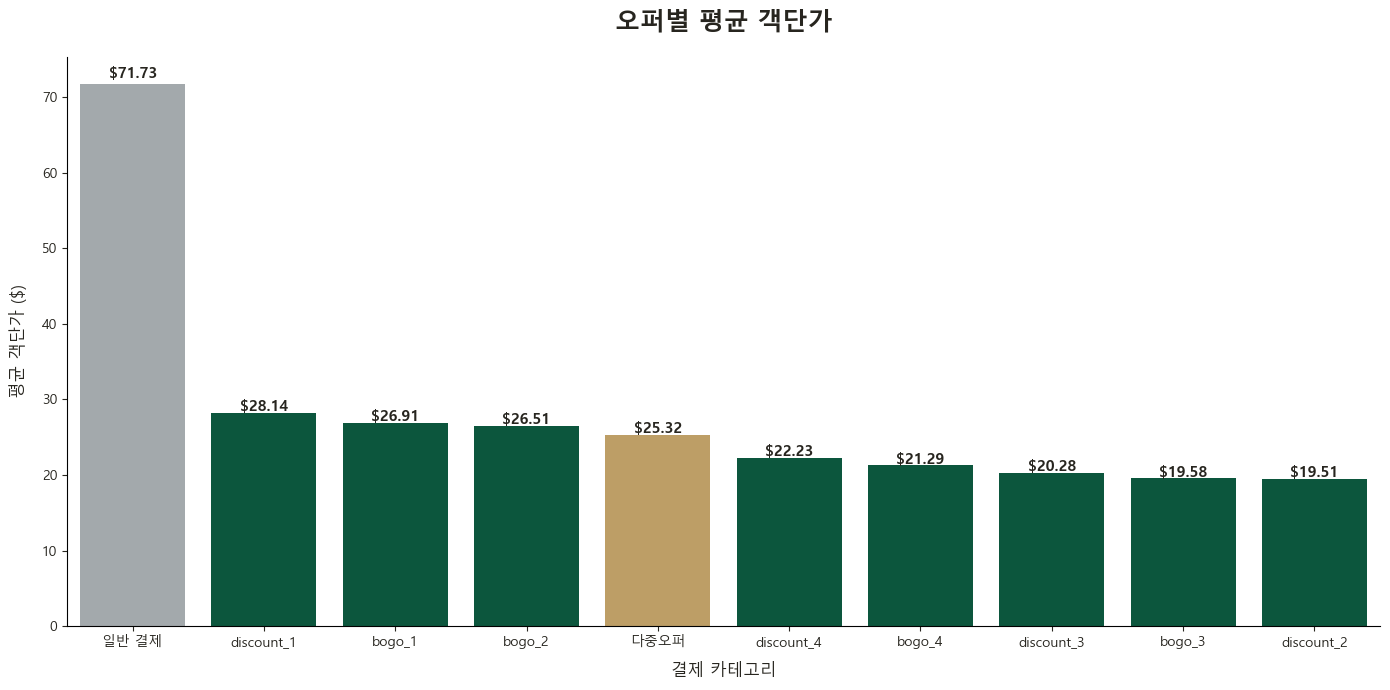

In [ ]:

# 2. 10개 카테고리 세분화 (일반 결제, 다중오퍼, 개별 오퍼 8개)
def get_detailed_label(row):
    if row['txn_offer_type'] == 'normal':
        return '일반 결제'
    elif row['txn_offer_type'] == 'multi':
        return '다중오퍼'
    else:
        # 단일 오퍼는 리스트 형태의 문자열에서 실제 라벨을 꺼내옵니다.
        # 예: "['bogo_1']" -> 'bogo_1'
        labels = ast.literal_eval(row['reward_offer_label_list'])
        return labels[0] if labels else row['txn_offer_type']

trans_df['detailed_category'] = trans_df.apply(get_detailed_label, axis=1)

# 3. 평균 객단가 계산 (총매출 / 고유 고객 수)
analysis = trans_df.groupby('detailed_category').agg(
    총매출=('amount', 'sum'),
    고객수=('person', 'nunique')
).reset_index()

analysis['평균객단가'] = analysis['총매출'] / analysis['고객수']

# 보기 좋게 객단가 높은 순으로 정렬합니다.
analysis = analysis.sort_values(by='평균객단가', ascending=False).reset_index(drop=True)

# 4. 시각화 ( 스타벅스 테마 컬러)
SB_GREEN  = '#006241'
SB_GOLD   = '#CBA258'
SB_GREY   = '#A2AAAD'
SB_BLACK  = '#27251F'

# 한글 폰트 설정 (환경에 맞춰 'Malgun Gothic' 또는 'AppleGothic' 사용)
plt.rcParams.update({
    'font.family': 'Malgun Gothic', 
    'axes.unicode_minus': False,
    'text.color': SB_BLACK,
    'axes.labelcolor': SB_BLACK,
})

plt.figure(figsize=(14, 7))

# 카테고리별 색상 배정 (일반: 회색, 다중오퍼: 골드, 개별오퍼: 그린)
def set_color(cat):
    if cat == '일반 결제': return SB_GREY
    elif cat == '다중오퍼': return SB_GOLD
    else: return SB_GREEN

colors = [set_color(cat) for cat in analysis['detailed_category']]

# 막대그래프 그리기
ax = sns.barplot(data=analysis, x='detailed_category', y='평균객단가', palette=colors)

plt.title('오퍼별 평균 객단가', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('결제 카테고리', fontsize=12, labelpad=10)
plt.ylabel('평균 객단가 ($)', fontsize=12, labelpad=10)

# 막대 위에 소수점 둘째 자리까지 금액 표시
for i, v in enumerate(analysis['평균객단가']):
    ax.text(i, v + (v * 0.01), f"${v:.2f}", ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

